In [11]:
import pandas as pd

df = pd.read_csv("Unemployment_in_india.csv")
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [17]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set visual style
sns.set_style("whitegrid")

# Set default figure size
plt.rcParams["figure.figsize"] = (12, 6)

# Display more columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")


# Load the unemployment dataset

df = pd.read_csv("Unemployment_in_india.csv")

# Display first 5 rows
df.head()




Libraries imported successfully!


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [19]:
# Check number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)
# Display basic information about the dataset

df.info()
# Display statistical summary

df.describe()



Number of rows: 768
Number of columns: 7
Dataset shape: (768, 7)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [20]:
# Display column names

print("Original columns:")
print(df.columns.tolist())


Original columns:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [21]:
# Remove unnecessary spaces from column names

df.columns = df.columns.str.strip()

print("Cleaned columns:")
print(df.columns.tolist())


Cleaned columns:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [22]:
# Check missing values in every column

missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

# Calculate percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)


Missing values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
Missing value percentage:
Region                                     3.645833
Date                                       3.645833
Frequency                                  3.645833
Estimated Unemployment Rate (%)            3.645833
Estimated Employed                         3.645833
Estimated Labour Participation Rate (%)    3.645833
Area                                       3.645833
dtype: float64


In [23]:
# Remove rows containing missing values

df = df.dropna().copy()
print("Dataset shape after removing missing values:", df.shape)
# Confirm that missing values have been removed

print(df.isnull().sum())

# Convert Date column from string to datetime

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

# Check data type
print(df["Date"].dtype)

# Display dates
df[["Date"]].head()



Dataset shape after removing missing values: (740, 7)
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64
datetime64[us]


,Date
0,2019-05-31
1,2019-06-30
2,2019-07-31
3,2019-08-31
4,2019-09-30


In [24]:
# List of numerical columns

numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

# Convert columns to numeric
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Check data types
print(df.dtypes)


Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object


In [25]:
# Remove rows with invalid numerical values

df = df.dropna(subset=numeric_columns)

print("Final dataset shape:", df.shape)


Final dataset shape: (740, 7)


In [26]:
# Display first 10 rows after cleaning

df.head(10)
# Display information about the cleaned dataset

df.info()


<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 62.1 KB


In [27]:
# Find the number of unique regions/states

print("Number of unique regions:", df["Region"].nunique())

print("\nRegions:")
print(sorted(df["Region"].unique()))


Number of unique regions: 28

Regions:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [28]:
# Calculate average unemployment rate for each region

region_average = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_average


Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

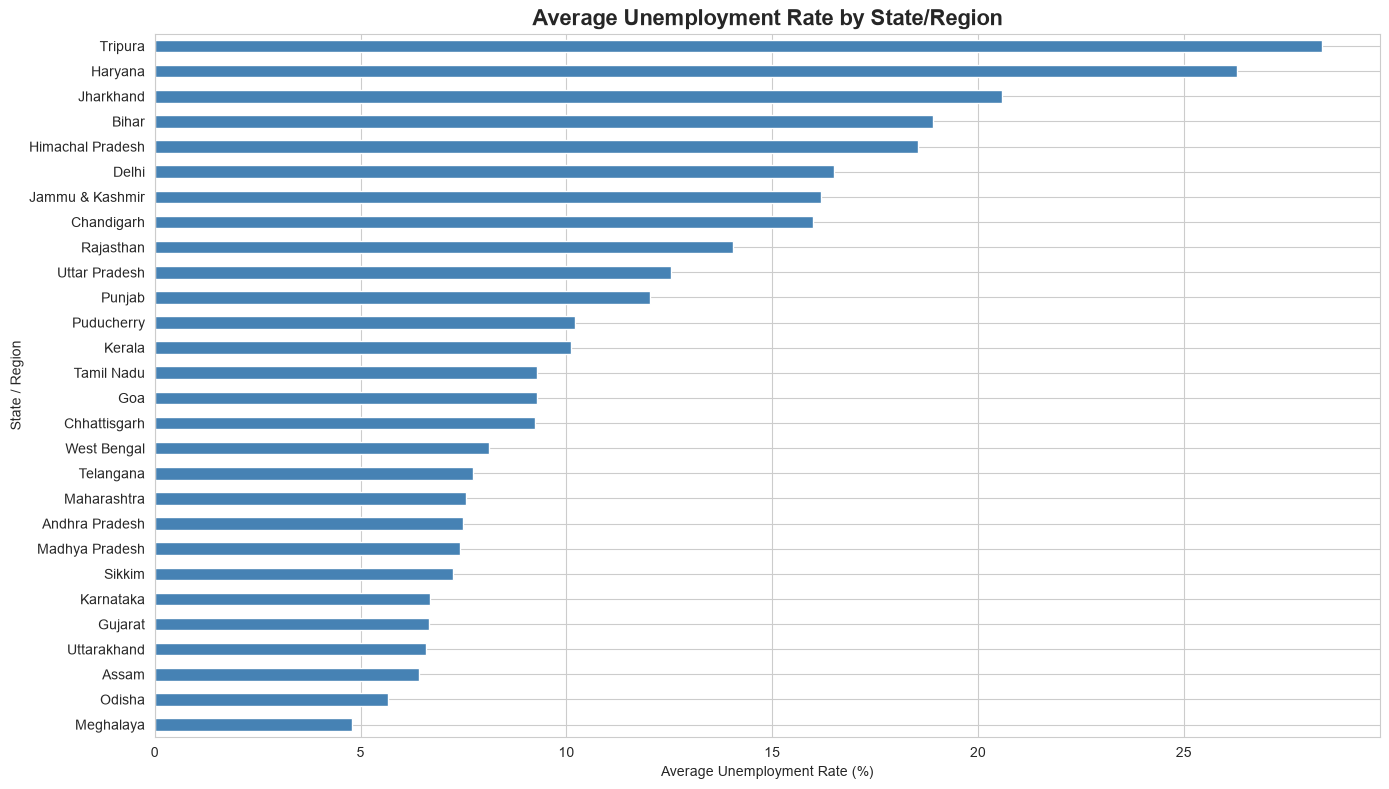

In [29]:
# Plot average unemployment rate by region

plt.figure(figsize=(14, 8))

region_average.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title(
    "Average Unemployment Rate by State/Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State / Region")

plt.tight_layout()
plt.show()


In [30]:
# Calculate average unemployment rate for each month

monthly_average = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_index()
)

monthly_average


Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64

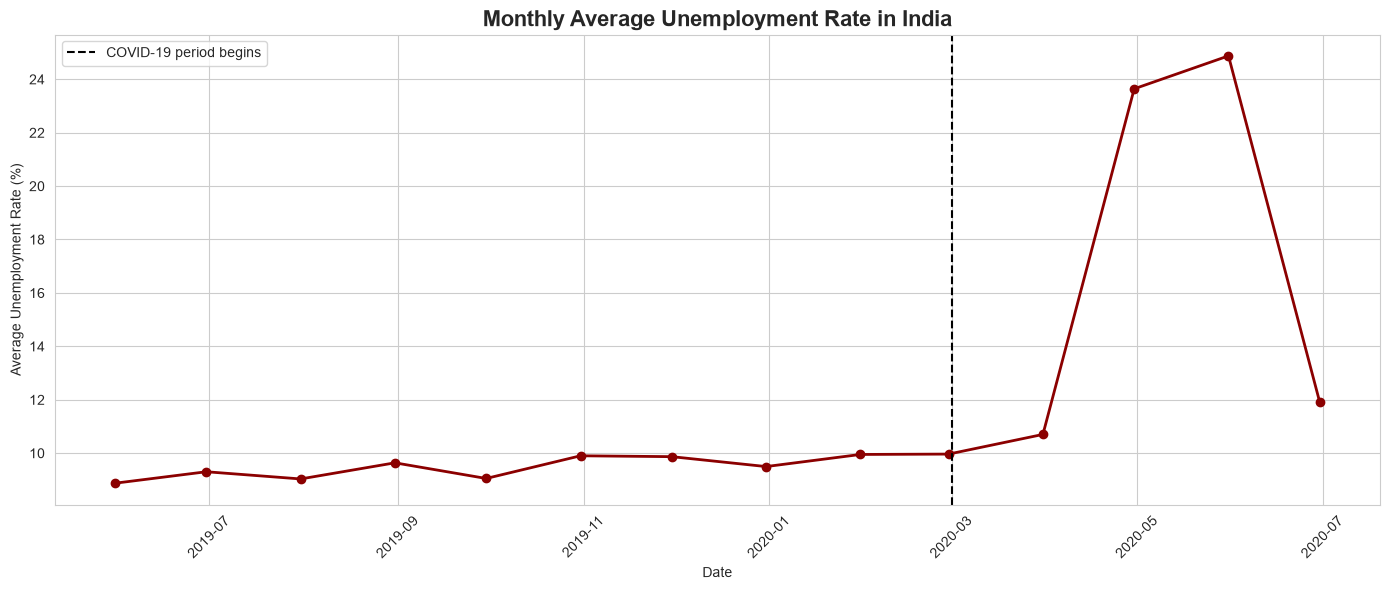

In [31]:
# Plot monthly unemployment trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker="o",
    linewidth=2,
    color="darkred"
)

# Mark COVID period
plt.axvline(
    pd.Timestamp("2020-03-01"),
    color="black",
    linestyle="--",
    label="COVID-19 period begins"
)

plt.title(
    "Monthly Average Unemployment Rate in India",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [32]:
# Select three major states for time-series analysis

selected_states = [
    "Maharashtra",
    "Tamil Nadu",
    "Uttar Pradesh"
]

state_data = df[df["Region"].isin(selected_states)].copy()

state_data.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
189,Maharashtra,2019-05-31,Monthly,3.67,23896858.0,47.11,Rural
190,Maharashtra,2019-06-30,Monthly,4.34,23056511.0,45.69,Rural
191,Maharashtra,2019-07-31,Monthly,3.66,24843750.0,48.80,Rural
192,Maharashtra,2019-08-31,Monthly,3.76,26835389.0,52.67,Rural
193,Maharashtra,2019-09-30,Monthly,4.40,25219281.0,49.74,Rural


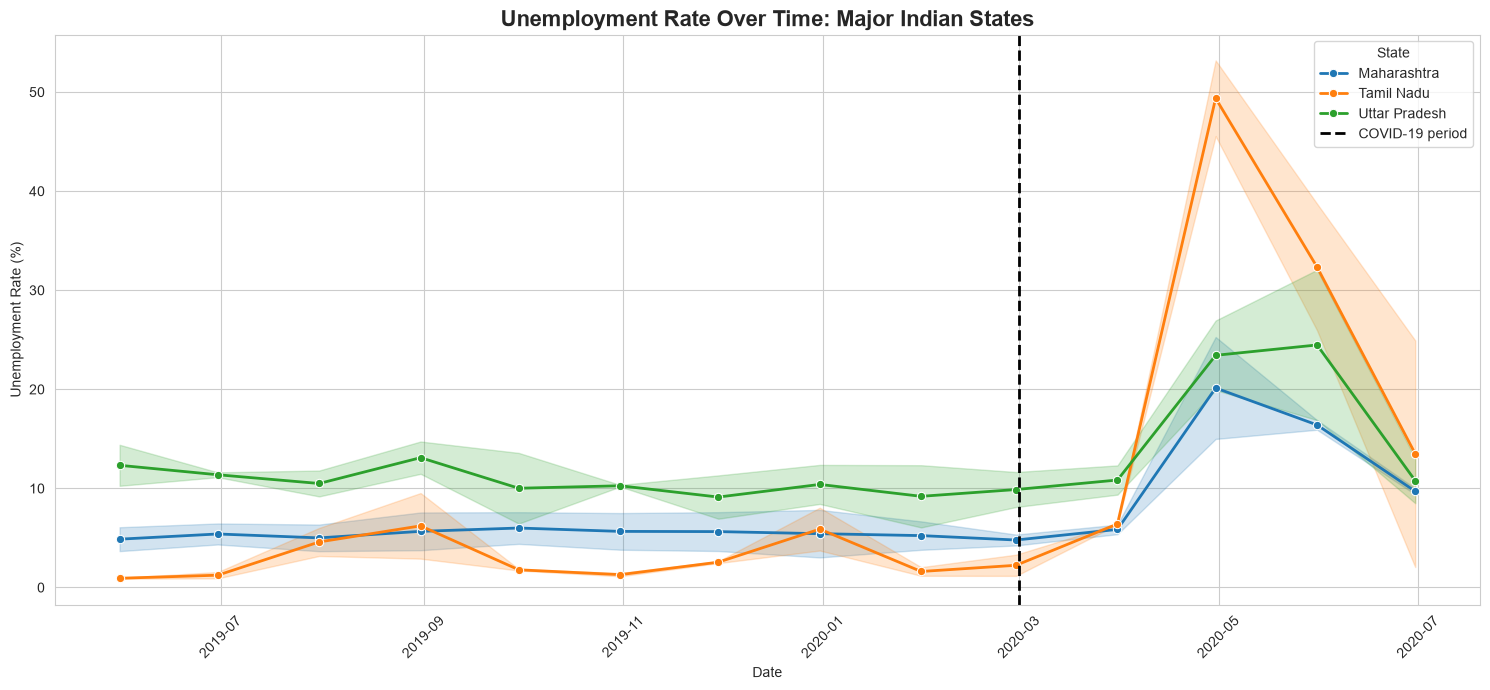

In [33]:
# Plot unemployment rate over time for three major states

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=state_data,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o",
    linewidth=2
)

# COVID reference line
plt.axvline(
    pd.Timestamp("2020-03-01"),
    color="black",
    linestyle="--",
    linewidth=2,
    label="COVID-19 period"
)

plt.title(
    "Unemployment Rate Over Time: Major Indian States",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.legend(title="State")

plt.tight_layout()
plt.show()


In [34]:
# Calculate average unemployment rate by region

top_10_states = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10_states


Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

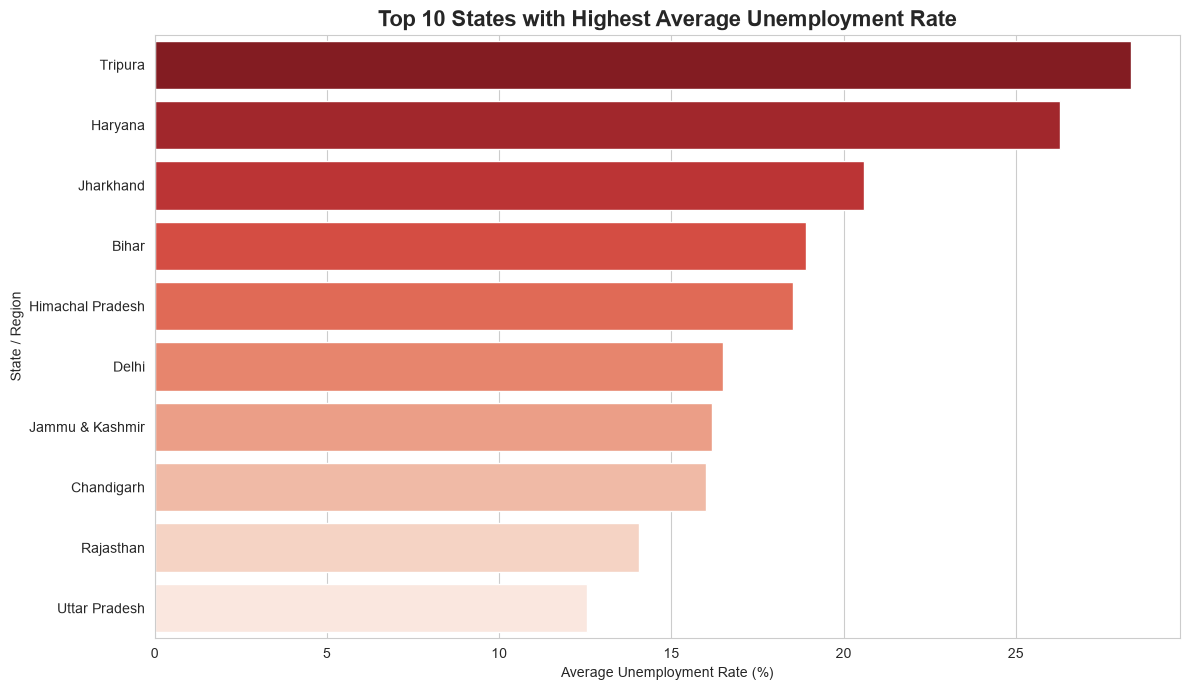

In [35]:
# Plot top 10 states with highest average unemployment

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10_states.values,
    y=top_10_states.index,
    hue=top_10_states.index,
    palette="Reds_r",
    legend=False
)

plt.title(
    "Top 10 States with Highest Average Unemployment Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State / Region")

plt.tight_layout()
plt.show()


In [36]:
# Select variables for correlation analysis

correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


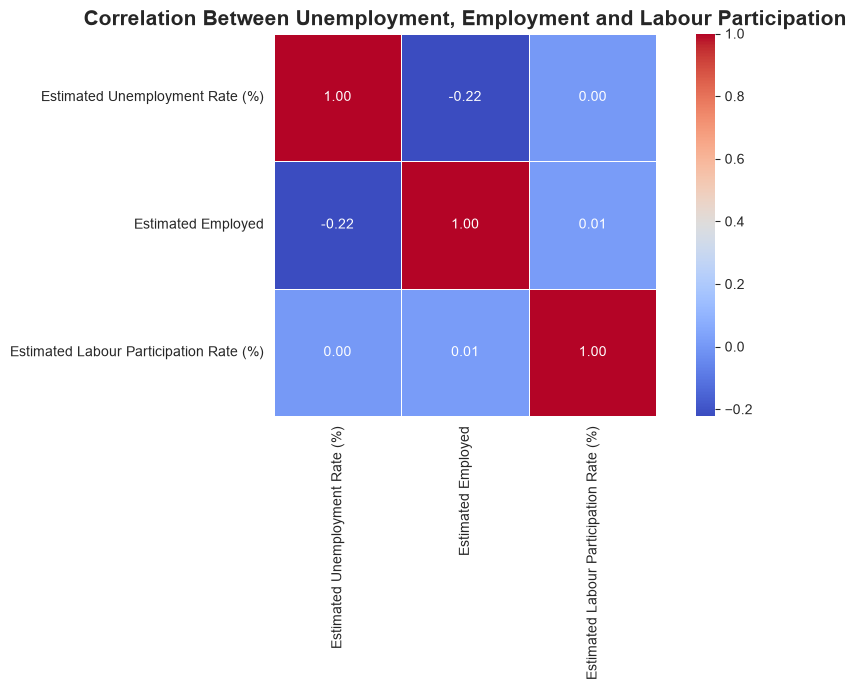

In [37]:
# Plot correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Between Unemployment, Employment and Labour Participation",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


In [38]:
# Create a COVID period classification

df["COVID_Period"] = np.where(
    df["Date"] < pd.Timestamp("2020-03-01"),
    "Pre-COVID",
    "Post-COVID"
)

# Display counts
print(df["COVID_Period"].value_counts())


COVID_Period
Pre-COVID     536
Post-COVID    204
Name: count, dtype: int64


In [39]:
# Calculate mean unemployment, employment and labour participation
# for Pre-COVID and Post-COVID periods

covid_comparison = (
    df.groupby("COVID_Period")[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)"
        ]
    ]
    .mean()
)

covid_comparison


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
COVID_Period,,,
Post-COVID,17.774363,6.517203e+06,39.330049
Pre-COVID,9.509534,7.466028e+06,43.886119


In [40]:
# Round values for easier interpretation

covid_comparison.round(2)


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
COVID_Period,,,
Post-COVID,17.77,6517203.34,39.33
Pre-COVID,9.51,7466027.87,43.89


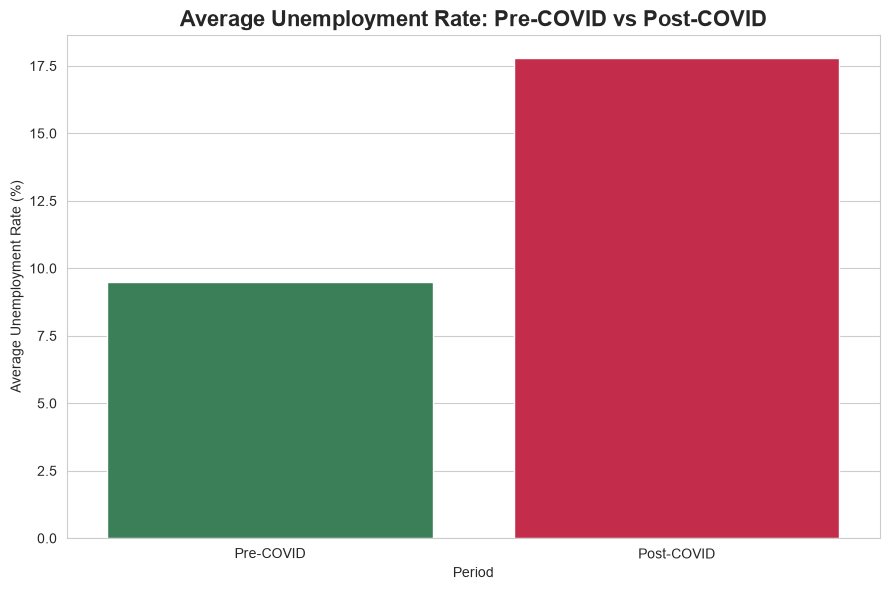

In [41]:
# Compare unemployment rate before and after COVID

plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="COVID_Period",
    y="Estimated Unemployment Rate (%)",
    hue="COVID_Period",
    palette=["seagreen", "crimson"],
    estimator=np.mean,
    errorbar=None,
    legend=False
)

plt.title(
    "Average Unemployment Rate: Pre-COVID vs Post-COVID",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()


In [42]:
# Extract pre-COVID and post-COVID unemployment rates

pre_covid_unemployment = covid_comparison.loc[
    "Pre-COVID",
    "Estimated Unemployment Rate (%)"
]

post_covid_unemployment = covid_comparison.loc[
    "Post-COVID",
    "Estimated Unemployment Rate (%)"
]

# Calculate absolute change
absolute_change = post_covid_unemployment - pre_covid_unemployment

# Calculate percentage change
percentage_change = (
    absolute_change / pre_covid_unemployment
) * 100

print("Pre-COVID average unemployment:",
      round(pre_covid_unemployment, 2), "%")

print("Post-COVID average unemployment:",
      round(post_covid_unemployment, 2), "%")

print("Absolute change:",
      round(absolute_change, 2), "percentage points")

print("Percentage change:",
      round(percentage_change, 2), "%")


Pre-COVID average unemployment: 9.51 %
Post-COVID average unemployment: 17.77 %
Absolute change: 8.26 percentage points
Percentage change: 86.91 %


In [43]:
# Calculate average unemployment by state and COVID period

state_covid_comparison = (
    df.groupby(["Region", "COVID_Period"])
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .unstack()
)

# Calculate change from Pre-COVID to Post-COVID

state_covid_comparison["Change"] = (
    state_covid_comparison["Post-COVID"]
    - state_covid_comparison["Pre-COVID"]
)

state_covid_comparison.sort_values(
    "Change",
    ascending=False
).head(10)


COVID_Period,Post-COVID,Pre-COVID,Change
Region,,,
Puducherry,38.95500,1.5930,37.36200
Tamil Nadu,25.40375,2.8365,22.56725
Jharkhand,36.34875,14.2795,22.06925
Bihar,31.63125,13.8330,17.79825
Karnataka,15.28000,3.2345,12.04550
Haryana,34.65250,22.9355,11.71700
Kerala,17.95250,6.9925,10.96000
Telangana,15.44250,4.6560,10.78650
Madhya Pradesh,14.07000,4.7410,9.32900


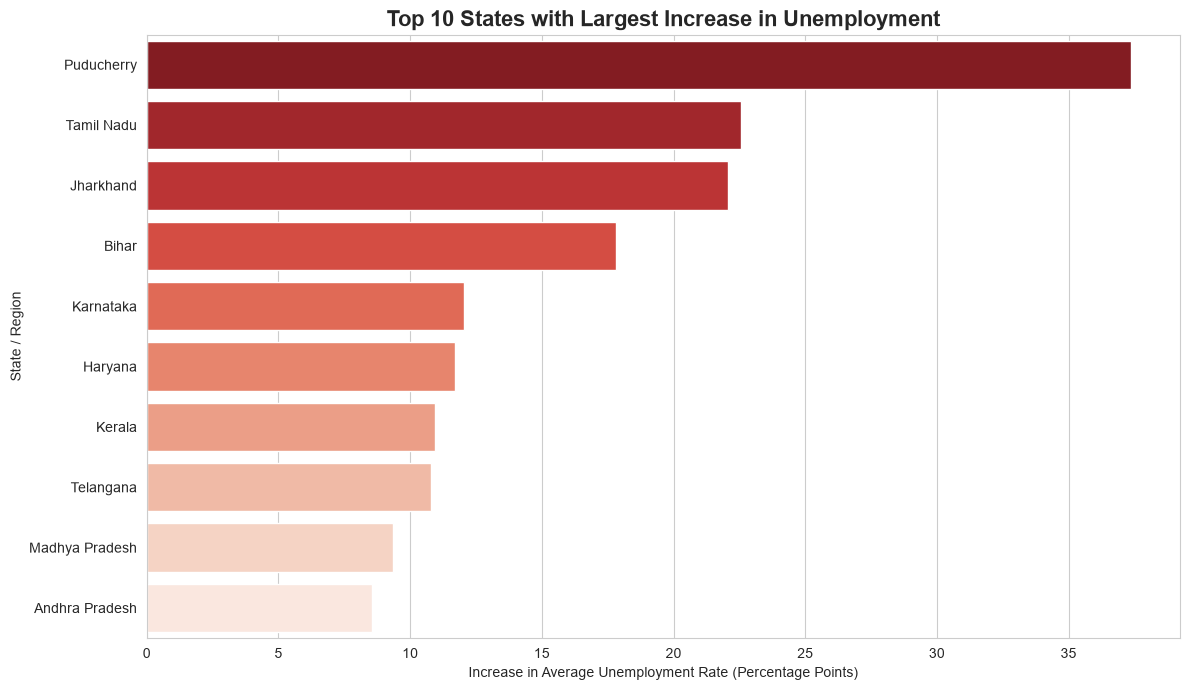

In [44]:
# Display top 10 states with the largest increase in unemployment

largest_increase = (
    state_covid_comparison
    .sort_values("Change", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=largest_increase["Change"],
    y=largest_increase.index,
    hue=largest_increase.index,
    palette="Reds_r",
    legend=False
)

plt.title(
    "Top 10 States with Largest Increase in Unemployment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Increase in Average Unemployment Rate (Percentage Points)")
plt.ylabel("State / Region")

plt.tight_layout()
plt.show()


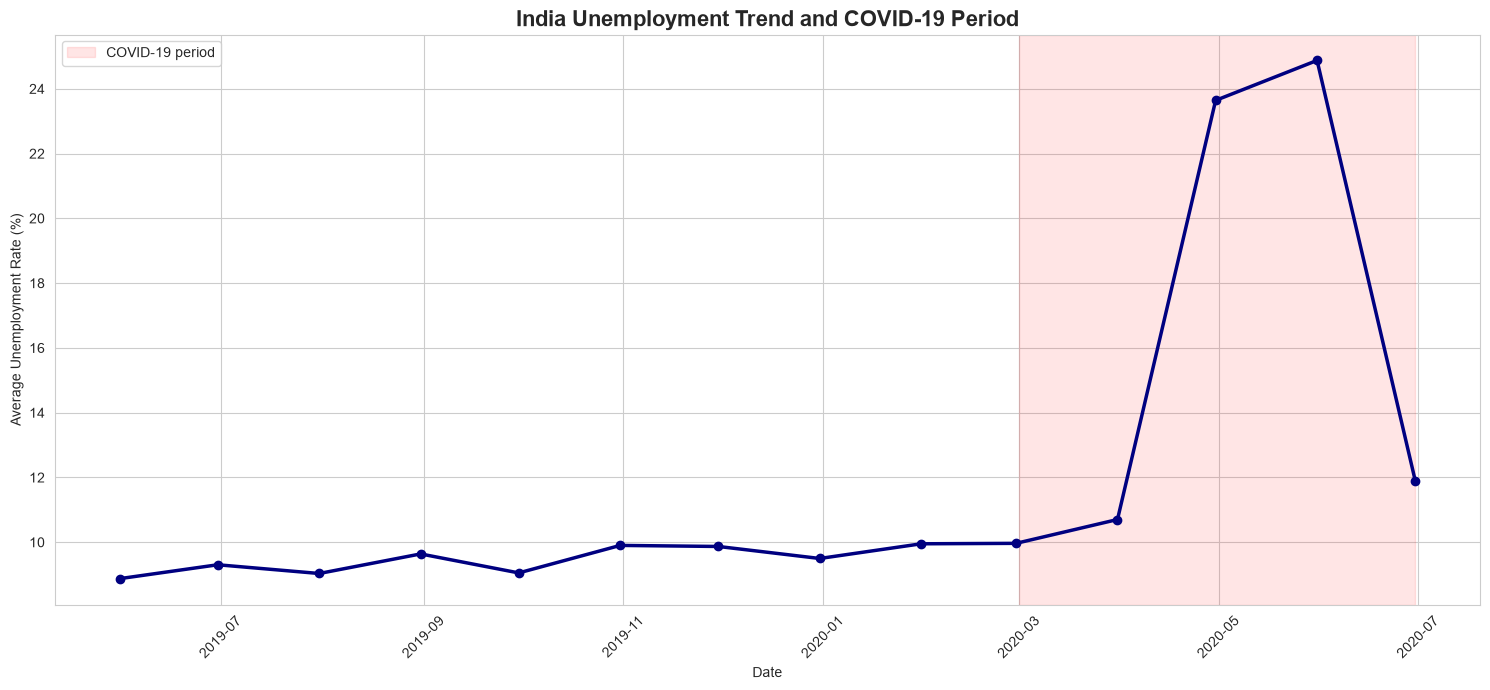

In [45]:
# Calculate monthly national average

monthly_trend = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(15, 7))

plt.plot(
    monthly_trend["Date"],
    monthly_trend["Estimated Unemployment Rate (%)"],
    marker="o",
    color="navy",
    linewidth=2.5
)

# Shade COVID period
plt.axvspan(
    pd.Timestamp("2020-03-01"),
    monthly_trend["Date"].max(),
    color="red",
    alpha=0.10,
    label="COVID-19 period"
)

plt.title(
    "India Unemployment Trend and COVID-19 Period",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [46]:
# Create a simple summary table

summary = pd.DataFrame({
    "Metric": [
        "Pre-COVID Average Unemployment",
        "Post-COVID Average Unemployment",
        "Absolute Increase",
        "Percentage Increase"
    ],
    "Value": [
        round(pre_covid_unemployment, 2),
        round(post_covid_unemployment, 2),
        round(absolute_change, 2),
        round(percentage_change, 2)
    ]
})

summary


,Metric,Value
0,Pre-COVID Average Unemployment,9.51
1,Post-COVID Average Unemployment,17.77
2,Absolute Increase,8.26
3,Percentage Increase,86.91
